# Dataset Exploratory Analysis 
### Oceans: Indian, Pacific, Atlantic
This notebook analyzes preprocessing pipeline outputs (profiles_clean.parquet, observations_clean.parquet, train.parquet, val.parquet, test.parquet, test_meta.parquet) across all three oceans to generate report figures and tables.

How to use:

    - Update the CONFIG cell with the output paths (OUTPUT_DIR) for each basin (the folders containing your preprocessed Parquet files).

    - Figures are saved to ./figures/ and summary tables to ./tables/ for direct inclusion in your report.


In [1]:
import os
import itertools
import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["axes.titleweight"] = "bold"

FIG_DIR = Path("figures"); FIG_DIR.mkdir(exist_ok=True)
TAB_DIR = Path("tables");  TAB_DIR.mkdir(exist_ok=True)

BASIN_COLORS = {
    "Indian":   "#1f77b4",
    "Pacific":  "#ff7f0e",
    "Atlantic": "#2ca02c",
}
STATUS_COLORS = {"Normal": "#4C9A2A", "Anomalie": "#D62728"}


## 1. Configuration

Specify the output folder (OUTPUT_DIR) generated by the preprocessing script for each ocean basin (containing profiles_clean.parquet, observations_clean.parquet, train.parquet, val.parquet, test.parquet, test_meta.parquet, and feature_cols.pkl).

TRAIN_END and VAL_END must match the pipeline constants (default: train = 2018–2020, val = 2021, test = 2022) to reconstruct each profile's split in profiles_clean.parquet without re-saving PLATFORM_NUMBER.


In [2]:
CONFIG = {
    "Indian": {
        "output_dir": "/work/drgarcia/Dataset/indian_ocean/2018-2022/2.preprocessed/split_time_ascA_dmodeD",
    },
    "Pacific": {
        "output_dir": "/work/drgarcia/Dataset/pacific_ocean/2018-2022/2.preprocessed/split_time_ascA_dmodeD",
    },
    "Atlantic": {
        "output_dir": "/work/drgarcia/Dataset/atlantic_ocean/2018-2022/2.preprocessed/split_time_ascA_dmodeD",
    },
}

TRAIN_END = pd.Timestamp("2021-01-01")   # train: 2018-2020
VAL_END   = pd.Timestamp("2022-01-01")   # val: 2021, test: 2022

# Metadata columns present in profiles_clean.parquet (no son features del modelo)
META_COLS = [
    "PLATFORM_NUMBER", "CYCLE_NUMBER", "is_bad", "PRES_is_bad", "TEMP_is_bad", "PSAL_is_bad",
    "JULD_ns", "date", "LATITUDE", "LONGITUDE", "DIRECTION", "DATA_CENTRE", "DATA_MODE",
    "PROFILE_PRES_QC", "PROFILE_TEMP_QC", "PROFILE_PSAL_QC", "DATE_CREATION", "DATE_UPDATE",
]
PROFILE_KEY = ["PLATFORM_NUMBER", "CYCLE_NUMBER", "DIRECTION"]


## 2. Data loading

For each ocean, we load:

-profiles_clean.parquet: Profile-level records containing vertical features and anomaly flags (is_bad, TEMP_is_bad, PSAL_is_bad, PRES_is_bad).

-observations_clean.parquet: Level-by-level observations used solely to compute n_levels per profile.

-test_meta.parquet: Test split metadata including PLATFORM_NUMBER.

-Split Reconstruction: Train/val/test splits are reconstructed using date, TRAIN_END, and VAL_END, matching the pipeline's split_temporal logic.


In [3]:
def n_levels_per_profile(df_obs: pd.DataFrame) -> pd.DataFrame:
    """Nombre de niveaux de pression (observations) par profil."""
    g = (
        df_obs.groupby(PROFILE_KEY, sort=False)["PRES"]
        .agg(n_levels="count", pres_min_obs="min", pres_max_obs="max")
        .reset_index()
    )
    return g


def anomaly_type(row) -> str:
    """Étiquette lisible du type d'anomalie en combinant les 3 flags."""
    flags = []
    if row["PRES_is_bad"]:
        flags.append("P")
    if row["TEMP_is_bad"]:
        flags.append("T")
    if row["PSAL_is_bad"]:
        flags.append("S")
    return "Normal" if not flags else "+".join(flags)


def assign_split(date_series: pd.Series) -> pd.Series:
    split = pd.Series("test", index=date_series.index)
    split[date_series < TRAIN_END] = "train"
    split[(date_series >= TRAIN_END) & (date_series < VAL_END)] = "val"
    return split


def load_basin(name: str, output_dir: str) -> dict:
    output_dir = Path(output_dir)
    profiles_path = output_dir / "profiles_clean.parquet"
    obs_path      = output_dir / "observations_clean.parquet"
    test_meta_path = output_dir / "test_meta.parquet"

    if not profiles_path.exists():
        print(f"[{name}] AVERTISSEMENT : {profiles_path} introuvable — bassin ignoré.")
        return None

    df = pd.read_parquet(profiles_path)
    df["date"] = pd.to_datetime(df["date"])
    df["BASIN"] = name
    df["anomaly_type"] = df.apply(anomaly_type, axis=1)
    df["status"] = np.where(df["is_bad"] == 1, "Anomalie", "Normal")
    df["split"] = assign_split(df["date"])

    if obs_path.exists():
        df_obs = pd.read_parquet(obs_path, columns=PROFILE_KEY + ["PRES"])
        lv = n_levels_per_profile(df_obs)
        df = df.merge(lv, on=PROFILE_KEY, how="left")
    else:
        print(f"[{name}] AVERTISSEMENT : {obs_path} introuvable, n_levels ignoré.")
        df["n_levels"] = np.nan

    test_meta = pd.read_parquet(test_meta_path) if test_meta_path.exists() else None

    return {"profiles": df, "test_meta": test_meta}


data = {}
for basin, cfg in CONFIG.items():
    result = load_basin(basin, cfg["output_dir"])
    if result is not None:
        data[basin] = result

print("Bassins chargés :", list(data.keys()))

Bassins chargés : ['Indian', 'Pacific', 'Atlantic']


In [4]:
# Jeu de données combiné (les 3 bassins), utile pour toutes les vues "globales"
df_all = pd.concat([d["profiles"] for d in data.values()], ignore_index=True)
print(f"Profils totaux combinés : {len(df_all):,}")
df_all.head()


Profils totaux combinés : 728,422


,PLATFORM_NUMBER,CYCLE_NUMBER,DIRECTION,TEMP_max,TEMP_min,TEMP_mean,TEMP_std,TEMP_range,TEMP_max_grad,TEMP_mean_grad,...,DATE_UPDATE,LATITUDE,LONGITUDE,BASIN,anomaly_type,status,split,n_levels,pres_min_obs,pres_max_obs
0,1900979,304.0,A,15.540,2.424,9.345847,3.695391,13.116,2.528000,0.185507,...,20260731170706,-42.110,140.454,Indian,Normal,Normal,train,72,4.0,1967.500000
1,1901150,264.0,A,15.486,2.437,6.570043,3.519224,13.049,2.361000,0.013325,...,20260722102412,-42.133,141.603,Indian,Normal,Normal,train,997,4.0,1995.699951
2,1901161,250.0,A,28.149,2.511,8.140253,7.051017,25.638,0.425999,0.029183,...,20260731170706,-17.804,50.812,Indian,Normal,Normal,train,987,4.4,1976.199951
3,1901168,245.0,A,4.574,1.689,2.360102,0.506058,2.885,0.281000,0.005982,...,20260722102412,-54.083,123.870,Indian,Normal,Normal,train,982,4.3,1966.300049
4,1901181,105.0,A,7.147,1.954,3.395322,1.451455,5.193,0.848000,0.063899,...,20260731170706,-48.345,103.655,Indian,Normal,Normal,train,90,16.0,1964.000000


## 3. General Dataset Statistics


In [5]:
summary_rows = []
for basin, d in data.items():
    df = d["profiles"]
    summary_rows.append({
        "Bassin": basin,
        "N profils": len(df),
        "N flotteurs uniques": df["PLATFORM_NUMBER"].nunique(),
        "Date de début": df["date"].min().date(),
        "Date de fin": df["date"].max().date(),
        "% d'anomalies": round(df["is_bad"].mean() * 100, 2),
        "N niveaux (moyenne)": round(df["n_levels"].mean(), 1),
        "N niveaux (médiane)": df["n_levels"].median(),
        "PRES max (moyenne)": round(df["PRES_max"].mean(), 1) if "PRES_max" in df else np.nan,
        "PRES max (p95)": round(df["PRES_max"].quantile(0.95), 1) if "PRES_max" in df else np.nan,
    })

df_summary = pd.DataFrame(summary_rows).set_index("Bassin")

total_row = {
    "N profils": len(df_all),
    "N flotteurs uniques": df_all["PLATFORM_NUMBER"].nunique(),
    "Date de début": df_all["date"].min().date(),
    "Date de fin": df_all["date"].max().date(),
    "% d'anomalies": round(df_all["is_bad"].mean() * 100, 2),
    "N niveaux (moyenne)": round(df_all["n_levels"].mean(), 1),
    "N niveaux (médiane)": df_all["n_levels"].median(),
    "PRES max (moyenne)": round(df_all["PRES_max"].mean(), 1) if "PRES_max" in df_all else np.nan,
    "PRES max (p95)": round(df_all["PRES_max"].quantile(0.95), 1) if "PRES_max" in df_all else np.nan,
}
df_summary.loc["TOTAL"] = total_row
df_summary.to_csv(TAB_DIR / "resume_general.csv")
df_summary

,N profils,N flotteurs uniques,Date de début,Date de fin,% d'anomalies,N niveaux (moyenne),N niveaux (médiane),PRES max (moyenne),PRES max (p95)
Bassin,,,,,,,,,
Indian,138567,1521,2018-01-01,2022-12-31,43.09,597.5,561.0,1835.4,2014.1
Pacific,360978,3617,2018-01-01,2022-12-31,44.47,658.2,711.0,1841.1,2013.8
Atlantic,228877,2410,2018-01-01,2022-12-31,27.69,507.8,504.0,1692.3,2029.1
TOTAL,728422,7071,2018-01-01,2022-12-31,38.93,599.4,562.0,1793.2,2020.1


## 4. Anomalous vs. Normal Percentage by Ocean Basin


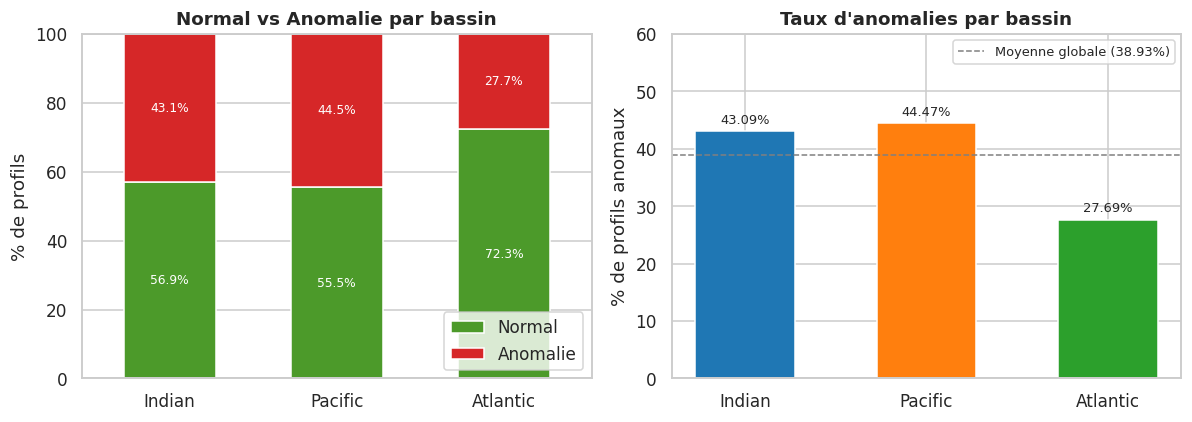

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# 1. Diagramme à barres empilées : % normal vs anomalie par bassin
pct = (
    pd.crosstab(df_all["BASIN"], df_all["status"], normalize="index") * 100
).reindex(index=list(data.keys()), columns=["Normal", "Anomalie"]).fillna(0)

pct[["Normal", "Anomalie"]].plot(
    kind="bar", stacked=True, ax=axes[0],
    color=[STATUS_COLORS["Normal"], STATUS_COLORS["Anomalie"]], edgecolor="white", width=0.55
)
axes[0].set_ylabel("% de profils")
axes[0].set_xlabel("")
axes[0].set_title("Normal vs Anomalie par bassin")
axes[0].legend(title="", loc="lower right")
axes[0].tick_params(axis="x", rotation=0)
axes[0].set_ylim(0, 100)

for c in axes[0].containers:
    axes[0].bar_label(c, fmt="%.1f%%", label_type="center", fontsize=8, color="white")

# 2. % d'anomalies total, comparaison directe entre bassins
anom_pct = df_all.groupby("BASIN")["is_bad"].mean().reindex(list(data.keys())) * 100
bars = axes[1].bar(anom_pct.index, anom_pct.values, width=0.55,
                    color=[BASIN_COLORS[b] for b in anom_pct.index], edgecolor="white")

axes[1].bar_label(bars, fmt="%.2f%%", padding=3, fontsize=8.5)
axes[1].set_ylabel("% de profils anomaux")
axes[1].set_title("Taux d'anomalies par bassin")
axes[1].tick_params(axis="x", rotation=0)

# Línea de media global
global_mean = df_all["is_bad"].mean() * 100
axes[1].axhline(global_mean, ls="--", color="grey", lw=1,
                  label=f"Moyenne globale ({global_mean:.2f}%)")

# Margen superior en Y para evitar que la leyenda o el texto toquen las barras
axes[1].set_ylim(0, max(anom_pct.max(), global_mean) * 1.35)
axes[1].legend(loc="upper right", fontsize=8.5)

plt.tight_layout()
plt.savefig(FIG_DIR / "anomalies_par_bassin.png", bbox_inches="tight", dpi=300)
plt.show()

Graphique sauvegardé dans : /home/drgarcia/Argo_ml_code_clean/4.Plots/general/figures/anomalies_ocean_bars.png


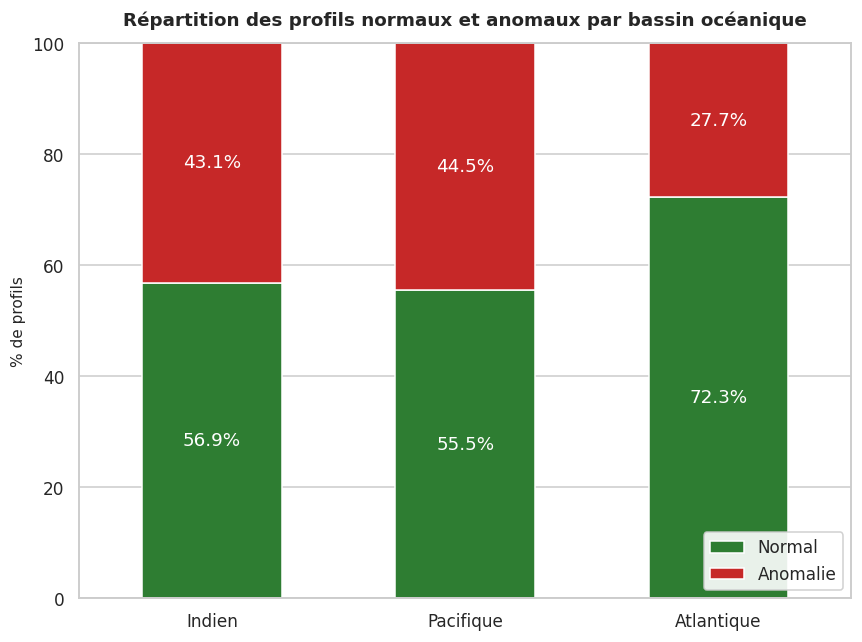

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

# Couleurs professionnelles adoucies
STATUS_COLORS = {
    "Normal": "#2e7d32",   # Vert forêt doux
    "Anomalie": "#c62828"  # Rouge bordeaux doux
}

# Dictionnaire de traduction des bassins
basin_translation = {
    "Indian": "Indien",
    "Pacific": "Pacifique",
    "Atlantic": "Atlantique"
}

fig, ax = plt.subplots(figsize=(8, 6))

# 1. Diagramme à barres empilées : % normal vs anomalie par bassin
pct = (
    pd.crosstab(df_all["BASIN"], df_all["status"], normalize="index") * 100
).reindex(index=list(data.keys()), columns=["Normal", "Anomalie"]).fillna(0)

# Traduction des noms de bassins dans le DataFrame
pct = pct.rename(index=basin_translation)

pct[["Normal", "Anomalie"]].plot(
    kind="bar", stacked=True, ax=ax,
    color=[STATUS_COLORS["Normal"], STATUS_COLORS["Anomalie"]], edgecolor="white", width=0.55
)

# Configuration des axes et du titre en français
ax.set_ylabel("% de profils", fontsize=10)
ax.set_xlabel("")
ax.set_title("Répartition des profils normaux et anomaux par bassin océanique", fontsize=12, pad=12)
ax.legend(title="", loc="lower right", frameon=True, facecolor="white", framealpha=0.9)
ax.tick_params(axis="x", rotation=0)
ax.set_ylim(0, 100)

for c in ax.containers:
    ax.bar_label(c, fmt="%.1f%%", label_type="center", fontsize=12, color="white")

output_path = FIG_DIR / "anomalies_ocean_bars.png"

plt.tight_layout()
plt.savefig(output_path, bbox_inches="tight", dpi=300)
print(f"Graphique sauvegardé dans : {output_path.resolve()}")
plt.show()

## 5. Anomaly Type Distribution (P, P+T, P+T+S, etc.)

Analyzes the 8 possible failure categories (Normal, P, T, S, P+T, P+S, T+S, P+T+S) per basin and overall.


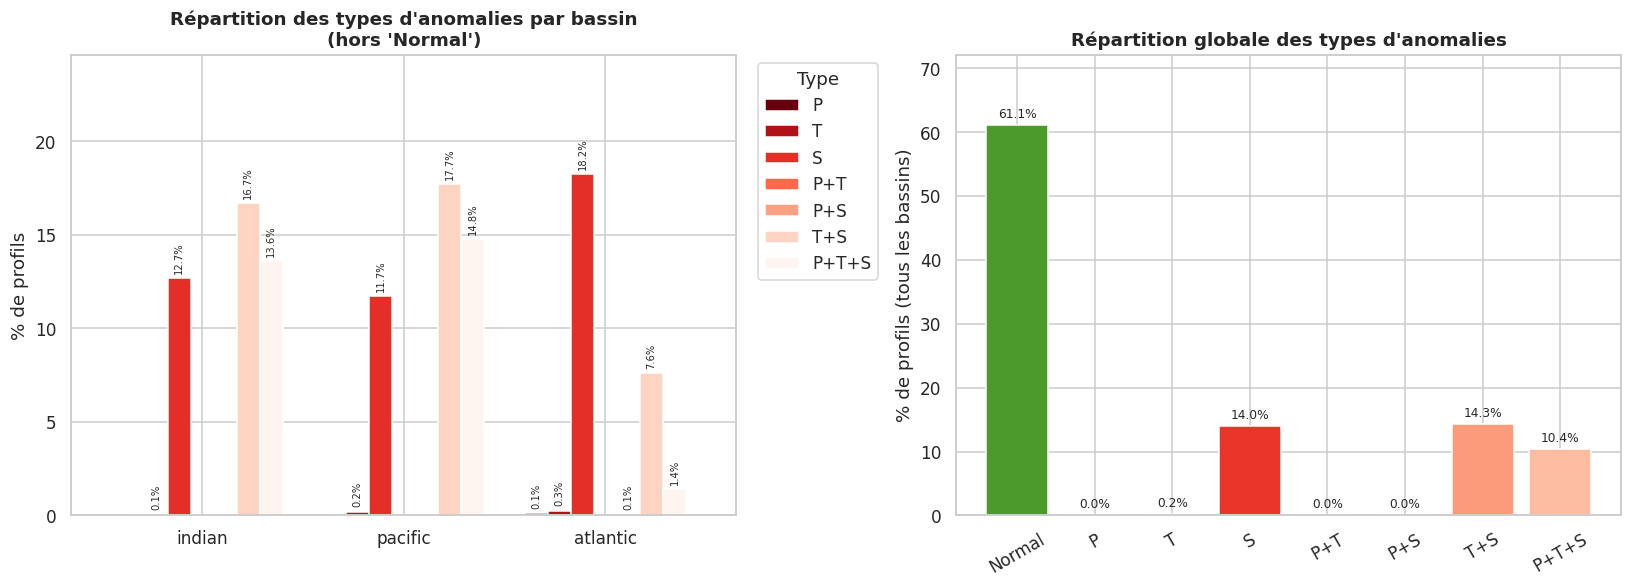

anomaly_type,Normal,P,T,S,P+T,P+S,T+S,P+T+S
BASIN,,,,,,,,
Indian,78859.0,10.0,110.0,17608.0,0.0,7.0,23137.0,18836.0
Pacific,200460.0,29.0,759.0,42327.0,4.0,23.0,63969.0,53407.0
Atlantic,165511.0,300.0,587.0,41729.0,8.0,143.0,17408.0,3191.0


In [22]:
ORDER = ["Normal", "P", "T", "S", "P+T", "P+S", "T+S", "P+T+S"]

type_counts = (
    df_all.groupby(["BASIN", "anomaly_type"]).size()
    .unstack("anomaly_type").reindex(columns=ORDER).fillna(0)
    .reindex(list(data.keys()))
)
type_pct = type_counts.div(type_counts.sum(axis=1), axis=0) * 100

# Convertir los nombres de los bassins a minúsculas en el índice
type_pct.index = [str(b).lower() for b in type_pct.index]

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# 1. Répartition des types d'anomalies par bassin
df_plot_bassin = type_pct.drop(columns="Normal")
df_plot_bassin.plot(
    kind="bar", ax=axes[0], colormap="Reds_r", edgecolor="white", width=0.8
)
axes[0].set_ylabel("% de profils")
axes[0].set_xlabel("")
axes[0].set_title("Répartition des types d'anomalies par bassin\n(hors 'Normal')")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(title="Type", bbox_to_anchor=(1.02, 1), loc="upper left")

# Margen superior para no cortar etiquetas
max_bassin = df_plot_bassin.values.max()
axes[0].set_ylim(0, max_bassin * 1.35)

# Añadir etiquetas pequeñas en vertical para evitar solapamiento
for c in axes[0].containers:
    labels = [f"{v:.1f}%" if v >= 0.05 else "" for v in c.datavalues]
    axes[0].bar_label(c, labels=labels, fontsize=6.5, rotation=90, padding=3)

# 2. Répartition globale des types d'anomalies
type_pct_total = df_all["anomaly_type"].value_counts(normalize=True).reindex(ORDER).fillna(0) * 100
bars = axes[1].bar(type_pct_total.index, type_pct_total.values,
                    color=["#4C9A2A"] + list(plt.cm.Reds_r(np.linspace(0.15, 0.75, 7))),
                    edgecolor="white")

max_total = type_pct_total.max()
axes[1].set_ylim(0, max_total * 1.18)
axes[1].bar_label(bars, fmt="%.1f%%", fontsize=8, padding=3)
axes[1].set_ylabel("% de profils (tous les bassins)")
axes[1].set_title("Répartition globale des types d'anomalies")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig(FIG_DIR / "types_d_anomalie.png", bbox_inches="tight", dpi=300)
plt.show()

type_counts.to_csv(TAB_DIR / "types_d_anomalie_comptage.csv")
type_pct.round(2).to_csv(TAB_DIR / "types_d_anomalie_pct.csv")
type_counts

## 6. Global Profile Map (Normal vs. Anomalous)


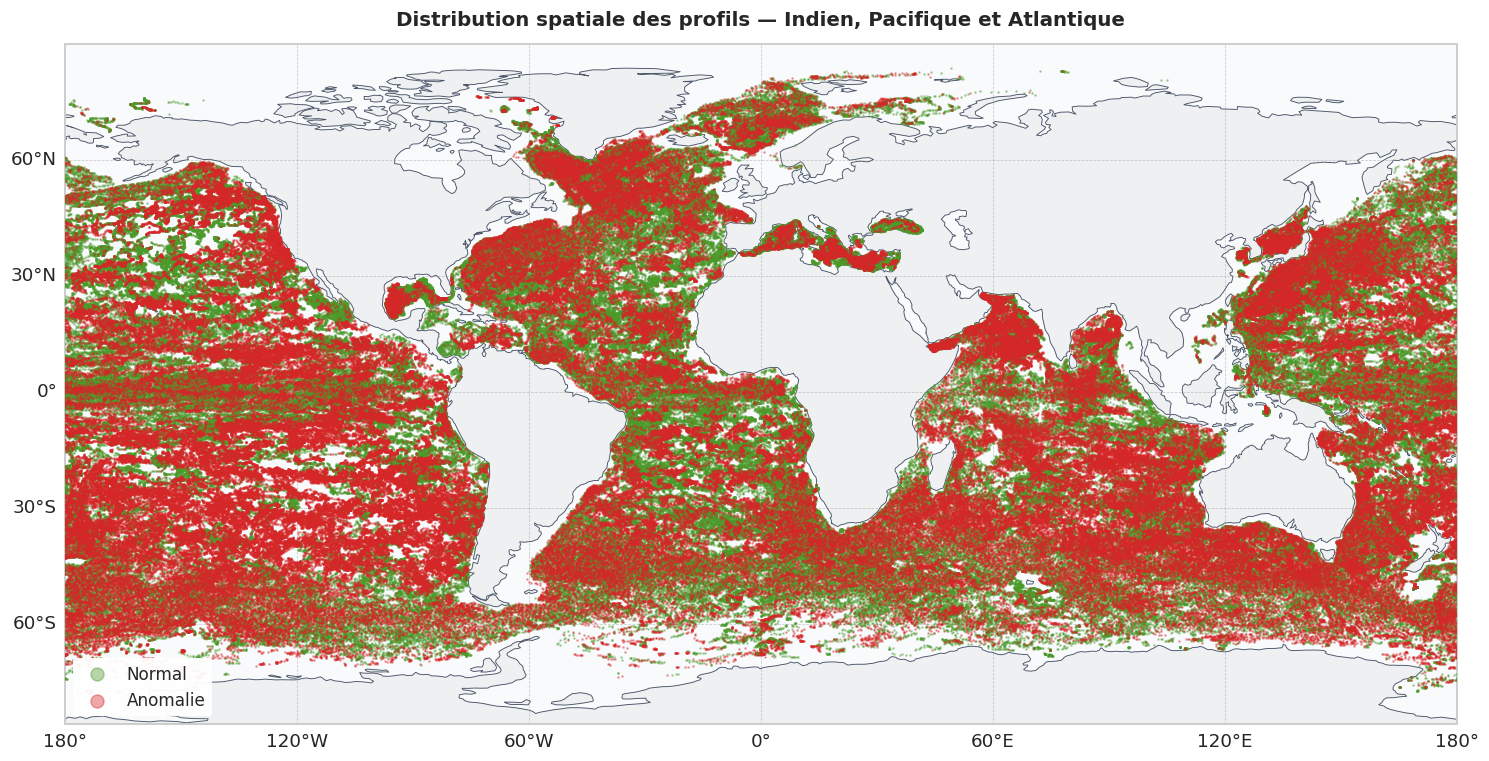

In [8]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig, ax = plt.subplots(
    figsize=(14, 7), 
    subplot_kw={"projection": ccrs.PlateCarree()}
)

# Fond de carte et continents
ax.add_feature(cfeature.OCEAN, facecolor="#f8fafc", zorder=0)
ax.add_feature(cfeature.LAND, facecolor="#eef0f2", zorder=1)
ax.add_feature(cfeature.COASTLINE, linewidth=0.6, edgecolor="#4a5568", zorder=2)

# Scatter plot con puntos más pequeños (s=0.5)
for status, color in STATUS_COLORS.items():
    sub = df_all[df_all["status"] == status]
    z_idx = 3 if status == "Normal" else 4
    
    ax.scatter(
        sub["LONGITUDE"], sub["LATITUDE"],
        s=0.5, alpha=0.4, color=color, label=status,
        transform=ccrs.PlateCarree(),
        rasterized=True,
        zorder=z_idx
    )

# Grille d'axes cartographiques
gl = ax.gridlines(
    draw_labels=True, dms=False, x_inline=False, y_inline=False,
    linewidth=0.5, color="gray", alpha=0.4, linestyle="--"
)
gl.top_labels = False
gl.right_labels = False

ax.set_title(
    "Distribution spatiale des profils — Indien, Pacifique et Atlantique",
    fontsize=13, fontweight="bold", pad=12
)

# Légende avec escala ampliada (markerscale=12) para que los símbolos se distingan bien
leg = ax.legend(
    markerscale=12, loc="lower left", frameon=True, 
    facecolor="white", framealpha=0.95, edgecolor="none"
)

plt.tight_layout()
plt.savefig(FIG_DIR / "carte_globale_normal_vs_anomalie.png", bbox_inches="tight", dpi=300)
plt.show()

## 7. Pressure Levels and Depth Statistics

Distribution of n_levels (pressure levels per profile) and maximum depth (PRES_max) per basin.


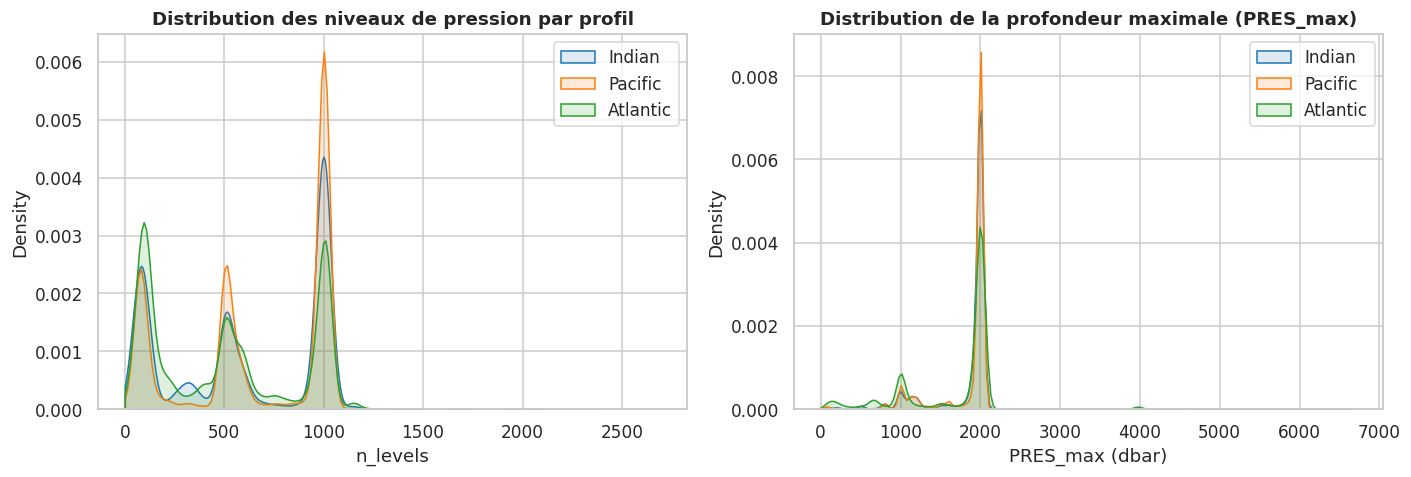

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for basin, d in data.items():
    df = d["profiles"]
    sns.kdeplot(df["n_levels"].dropna(), ax=axes[0], label=basin,
                color=BASIN_COLORS[basin], fill=True, alpha=0.15, clip=(0, None))
    sns.kdeplot(df["PRES_max"].dropna(), ax=axes[1], label=basin,
                color=BASIN_COLORS[basin], fill=True, alpha=0.15, clip=(0, None))

axes[0].set_title("Distribution des niveaux de pression par profil")
axes[0].set_xlabel("n_levels")
axes[0].legend()

axes[1].set_title("Distribution de la profondeur maximale (PRES_max)")
axes[1].set_xlabel("PRES_max (dbar)")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "distribution_niveaux_profondeur.png", bbox_inches="tight")
plt.show()

## 8. Platforms (Floats) in Train / Val / Test — New vs. Seen

-Temporal Split Dynamics: Individual floats continue transmitting profiles over time, meaning a float can appear in both train and subsequent val/test splits.

-Classification: Counts the number of floats per split and basin categorized as "already seen in train" versus entirely "new".


In [10]:
def platform_split_stats(df: pd.DataFrame) -> pd.DataFrame:
    train_plats = set(df.loc[df["split"] == "train", "PLATFORM_NUMBER"])
    rows = []
    for split_name in ["train", "val", "test"]:
        plats = set(df.loc[df["split"] == split_name, "PLATFORM_NUMBER"])
        seen = plats & train_plats if split_name != "train" else set()
        rows.append({
            "split": split_name,
            "n_profils": (df["split"] == split_name).sum(),
            "n_flotteurs": len(plats),
            "n_flotteurs_deja_vus_en_train": len(seen),
            "n_flotteurs_nouveaux": len(plats) - len(seen) if split_name != "train" else len(plats),
        })
    return pd.DataFrame(rows).set_index("split")

platform_stats = {basin: platform_split_stats(d["profiles"]) for basin, d in data.items()}
platform_stats["TOTAL"] = platform_split_stats(df_all)

for basin, tbl in platform_stats.items():
    print(f"--- {basin} ---")
    display(tbl)
    tbl.to_csv(TAB_DIR / f"flotteurs_train_val_test_{basin.lower()}.csv")

--- Indian ---


,n_profils,n_flotteurs,n_flotteurs_deja_vus_en_train,n_flotteurs_nouveaux
split,,,,
train,88992,1340,0,1340
val,26795,838,760,78
test,22780,743,574,169


--- Pacific ---


,n_profils,n_flotteurs,n_flotteurs_deja_vus_en_train,n_flotteurs_nouveaux
split,,,,
train,220940,2928,0,2928
val,70440,2156,1757,399
test,69598,2095,1436,659


--- Atlantic ---


,n_profils,n_flotteurs,n_flotteurs_deja_vus_en_train,n_flotteurs_nouveaux
split,,,,
train,139114,1882,0,1882
val,46113,1280,991,289
test,43650,1237,742,495


--- TOTAL ---


,n_profils,n_flotteurs,n_flotteurs_deja_vus_en_train,n_flotteurs_nouveaux
split,,,,
train,449046,5839,0,5839
val,143348,4175,3497,678
test,136028,3992,2805,1187


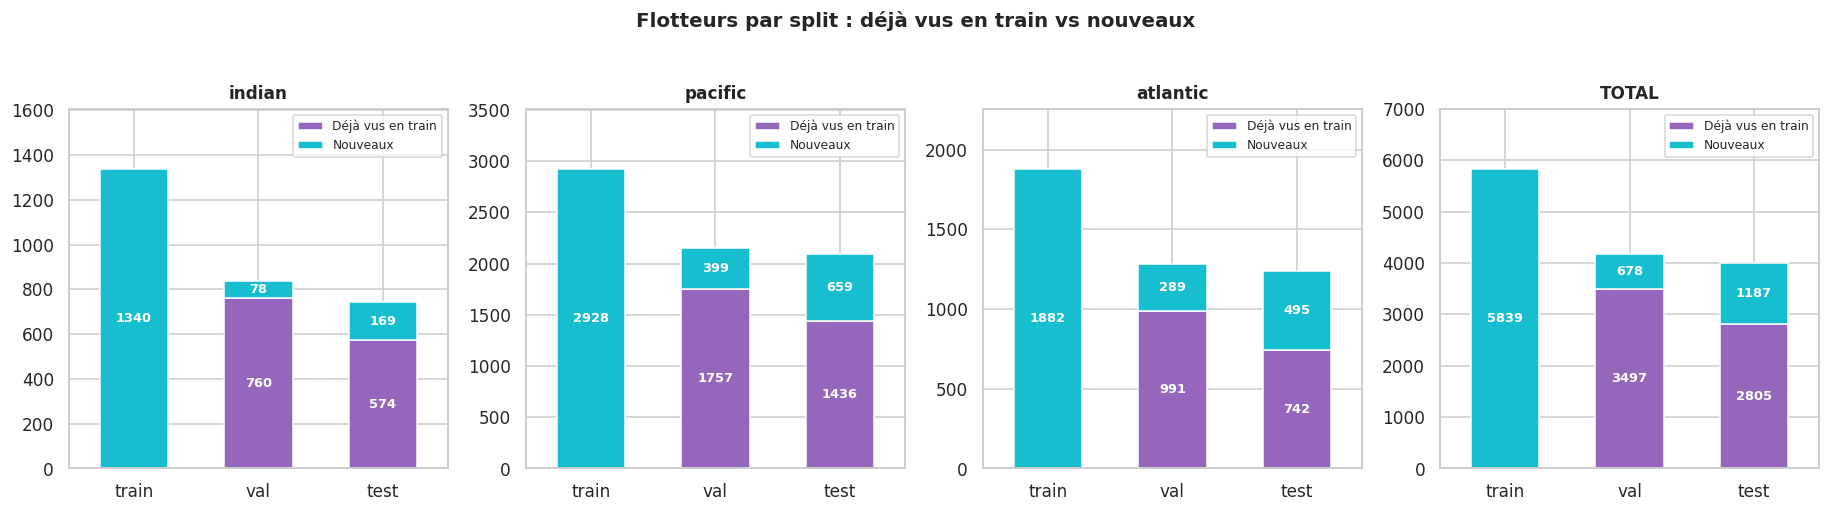

In [11]:
fig, axes = plt.subplots(1, len(data) + 1, figsize=(4.2 * (len(data) + 1), 4.5), sharey=False)

for ax, (basin, tbl) in zip(axes, platform_stats.items()):
    new_vs_seen = tbl[["n_flotteurs_deja_vus_en_train", "n_flotteurs_nouveaux"]].copy()
    new_vs_seen.loc["train", "n_flotteurs_nouveaux"] = tbl.loc["train", "n_flotteurs"]
    
    new_vs_seen.plot(kind="bar", stacked=True, ax=ax,
                      color=["#9467bd", "#17becf"], edgecolor="white", width=0.55)
    
    # Ajout des effectifs au centre de chaque segment (masque les valeurs 0)
    for c in ax.containers:
        labels = [f"{int(v)}" if v > 0 else "" for v in c.datavalues]
        ax.bar_label(c, labels=labels, label_type="center", fontsize=8.5, color="white", fontweight="bold")
    
    max_val = tbl["n_flotteurs"].max()
    ax.set_ylim(0, max_val * 1.2)
    
    ax.set_title(basin.lower() if basin != "TOTAL" else "TOTAL", fontsize=11, fontweight="bold")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)
    ax.legend(["Déjà vus en train", "Nouveaux"], fontsize=8, loc="upper right")

fig.suptitle("Flotteurs par split : déjà vus en train vs nouveaux", y=1.03, fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / "flotteurs_train_val_test.png", bbox_inches="tight", dpi=300)
plt.show()

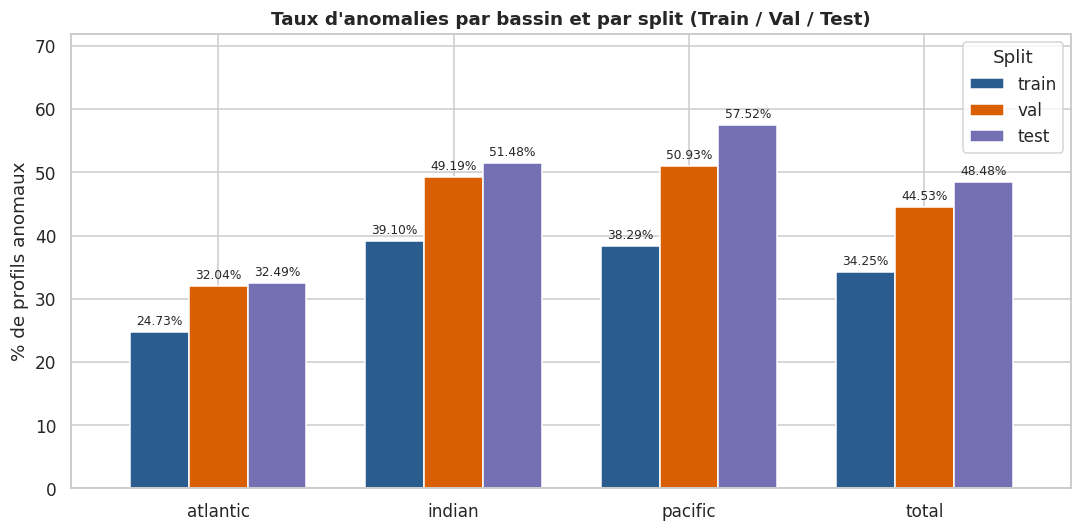

In [12]:
# Calcul du taux d'anomalies (% de profils anomaux) par bassin et par split
anomaly_by_split = (
    df_all.groupby(["BASIN", "split"])["is_bad"]
    .mean()
    .unstack("split")[["train", "val", "test"]] * 100
)

# Conversion du nom des bassins en minuscules
anomaly_by_split.index = [str(b).lower() for b in anomaly_by_split.index]

# Ajout de la ligne totale globale
total_split = df_all.groupby("split")["is_bad"].mean()[["train", "val", "test"]] * 100
anomaly_by_split.loc["total"] = total_split

fig, ax = plt.subplots(figsize=(10, 5))

anomaly_by_split.plot(
    kind="bar", ax=ax, width=0.75,
    color=["#2b5c8f", "#d95f02", "#7570b3"], edgecolor="white"
)

ax.set_ylabel("% de profils anomaux")
ax.set_xlabel("")
ax.set_title("Taux d'anomalies par bassin et par split (Train / Val / Test)", fontsize=12, fontweight="bold")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Split", loc="upper right")

# Marge supérieure pour afficher clairement les pourcentages au-dessus des barres
ax.set_ylim(0, anomaly_by_split.values.max() * 1.25)

for c in ax.containers:
    ax.bar_label(c, fmt="%.2f%%", fontsize=8, padding=3)

plt.tight_layout()
plt.savefig(FIG_DIR / "taux_anomalies_par_bassin_split.png", bbox_inches="tight", dpi=300)
plt.show()

Graphique sauvegardé dans : /home/drgarcia/Argo_ml_code_clean/4.Plots/general/figures/taux_anomalies_par_bassin_split.png


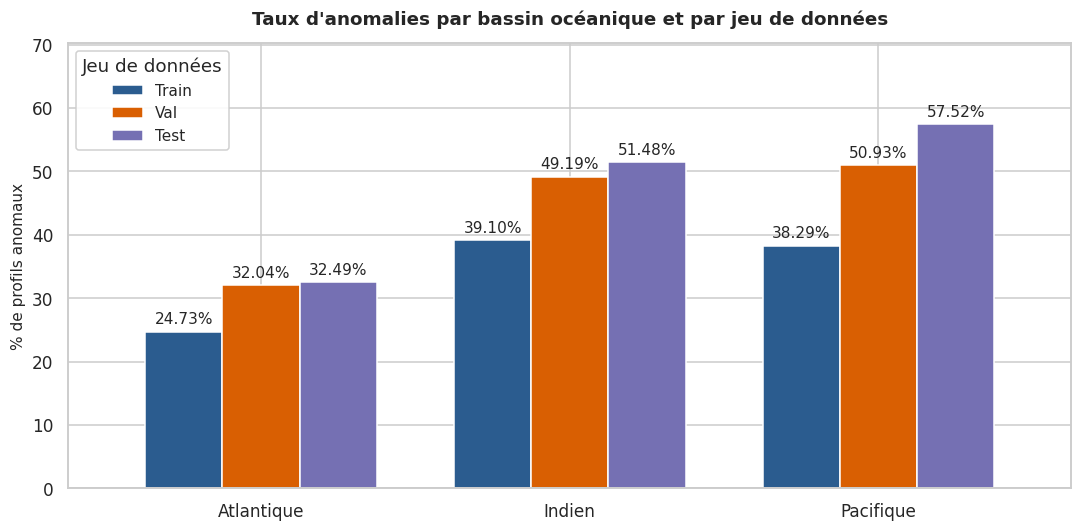

In [19]:
import matplotlib.pyplot as plt
import pandas as pd

# Couleurs professionnelles pour les splits
SPLIT_COLORS = ["#2b5c8f", "#d95f02", "#7570b3"]

# Dictionnaire de traduction et de formatage des noms de bassins en français
basin_translation = {
    "Indian": "Indien",
    "Pacific": "Pacifique",
    "Atlantic": "Atlantique"
}

# Calcul du taux d'anomalies (% de profils anomaux) par bassin et par split
anomaly_by_split = (
    df_all.groupby(["BASIN", "split"])["is_bad"]
    .mean()
    .unstack("split")[["train", "val", "test"]] * 100
)

# Application de la traduction en français (sans la ligne total)
anomaly_by_split.index = anomaly_by_split.index.map(lambda b: basin_translation.get(b, b))

fig, ax = plt.subplots(figsize=(10, 5))

anomaly_by_split.plot(
    kind="bar", ax=ax, width=0.75,
    color=SPLIT_COLORS, edgecolor="white"
)

# Configuration des axes et du titre en français
ax.set_ylabel("% de profils anomaux", fontsize=10)
ax.set_xlabel("")
ax.set_title("Taux d'anomalies par bassin océanique et par jeu de données", fontsize=12, pad=12)
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Jeu de données", labels=["Train", "Val", "Test"], loc="upper left", frameon=True, facecolor="white", framealpha=0.9,  fontsize=10)

# Marge supérieure pour afficher clairement les étiquettes au-dessus des barres
ax.set_ylim(0, anomaly_by_split.values.max() * 1.22)

for c in ax.containers:
    ax.bar_label(c, fmt="%.2f%%", fontsize=10, padding=3)

output_path = FIG_DIR / "taux_anomalies_par_bassin_split.png"

plt.tight_layout()
plt.savefig(output_path, bbox_inches="tight", dpi=300)
print(f"Graphique sauvegardé dans : {output_path.resolve()}")
plt.show()

## 9. Multi-Panel Basin Plot (Map + Anomalies + Types + Levels)

- Layout: A single comprehensive figure with one row per ocean basin (Indian, Pacific, Atlantic) and 4 columns.

- Content: Profile map, normal vs. anomalous percentage, anomaly type distribution, and n_levels distribution.

- Purpose: Designed for direct inclusion as the primary basin-level analysis figure in the report.


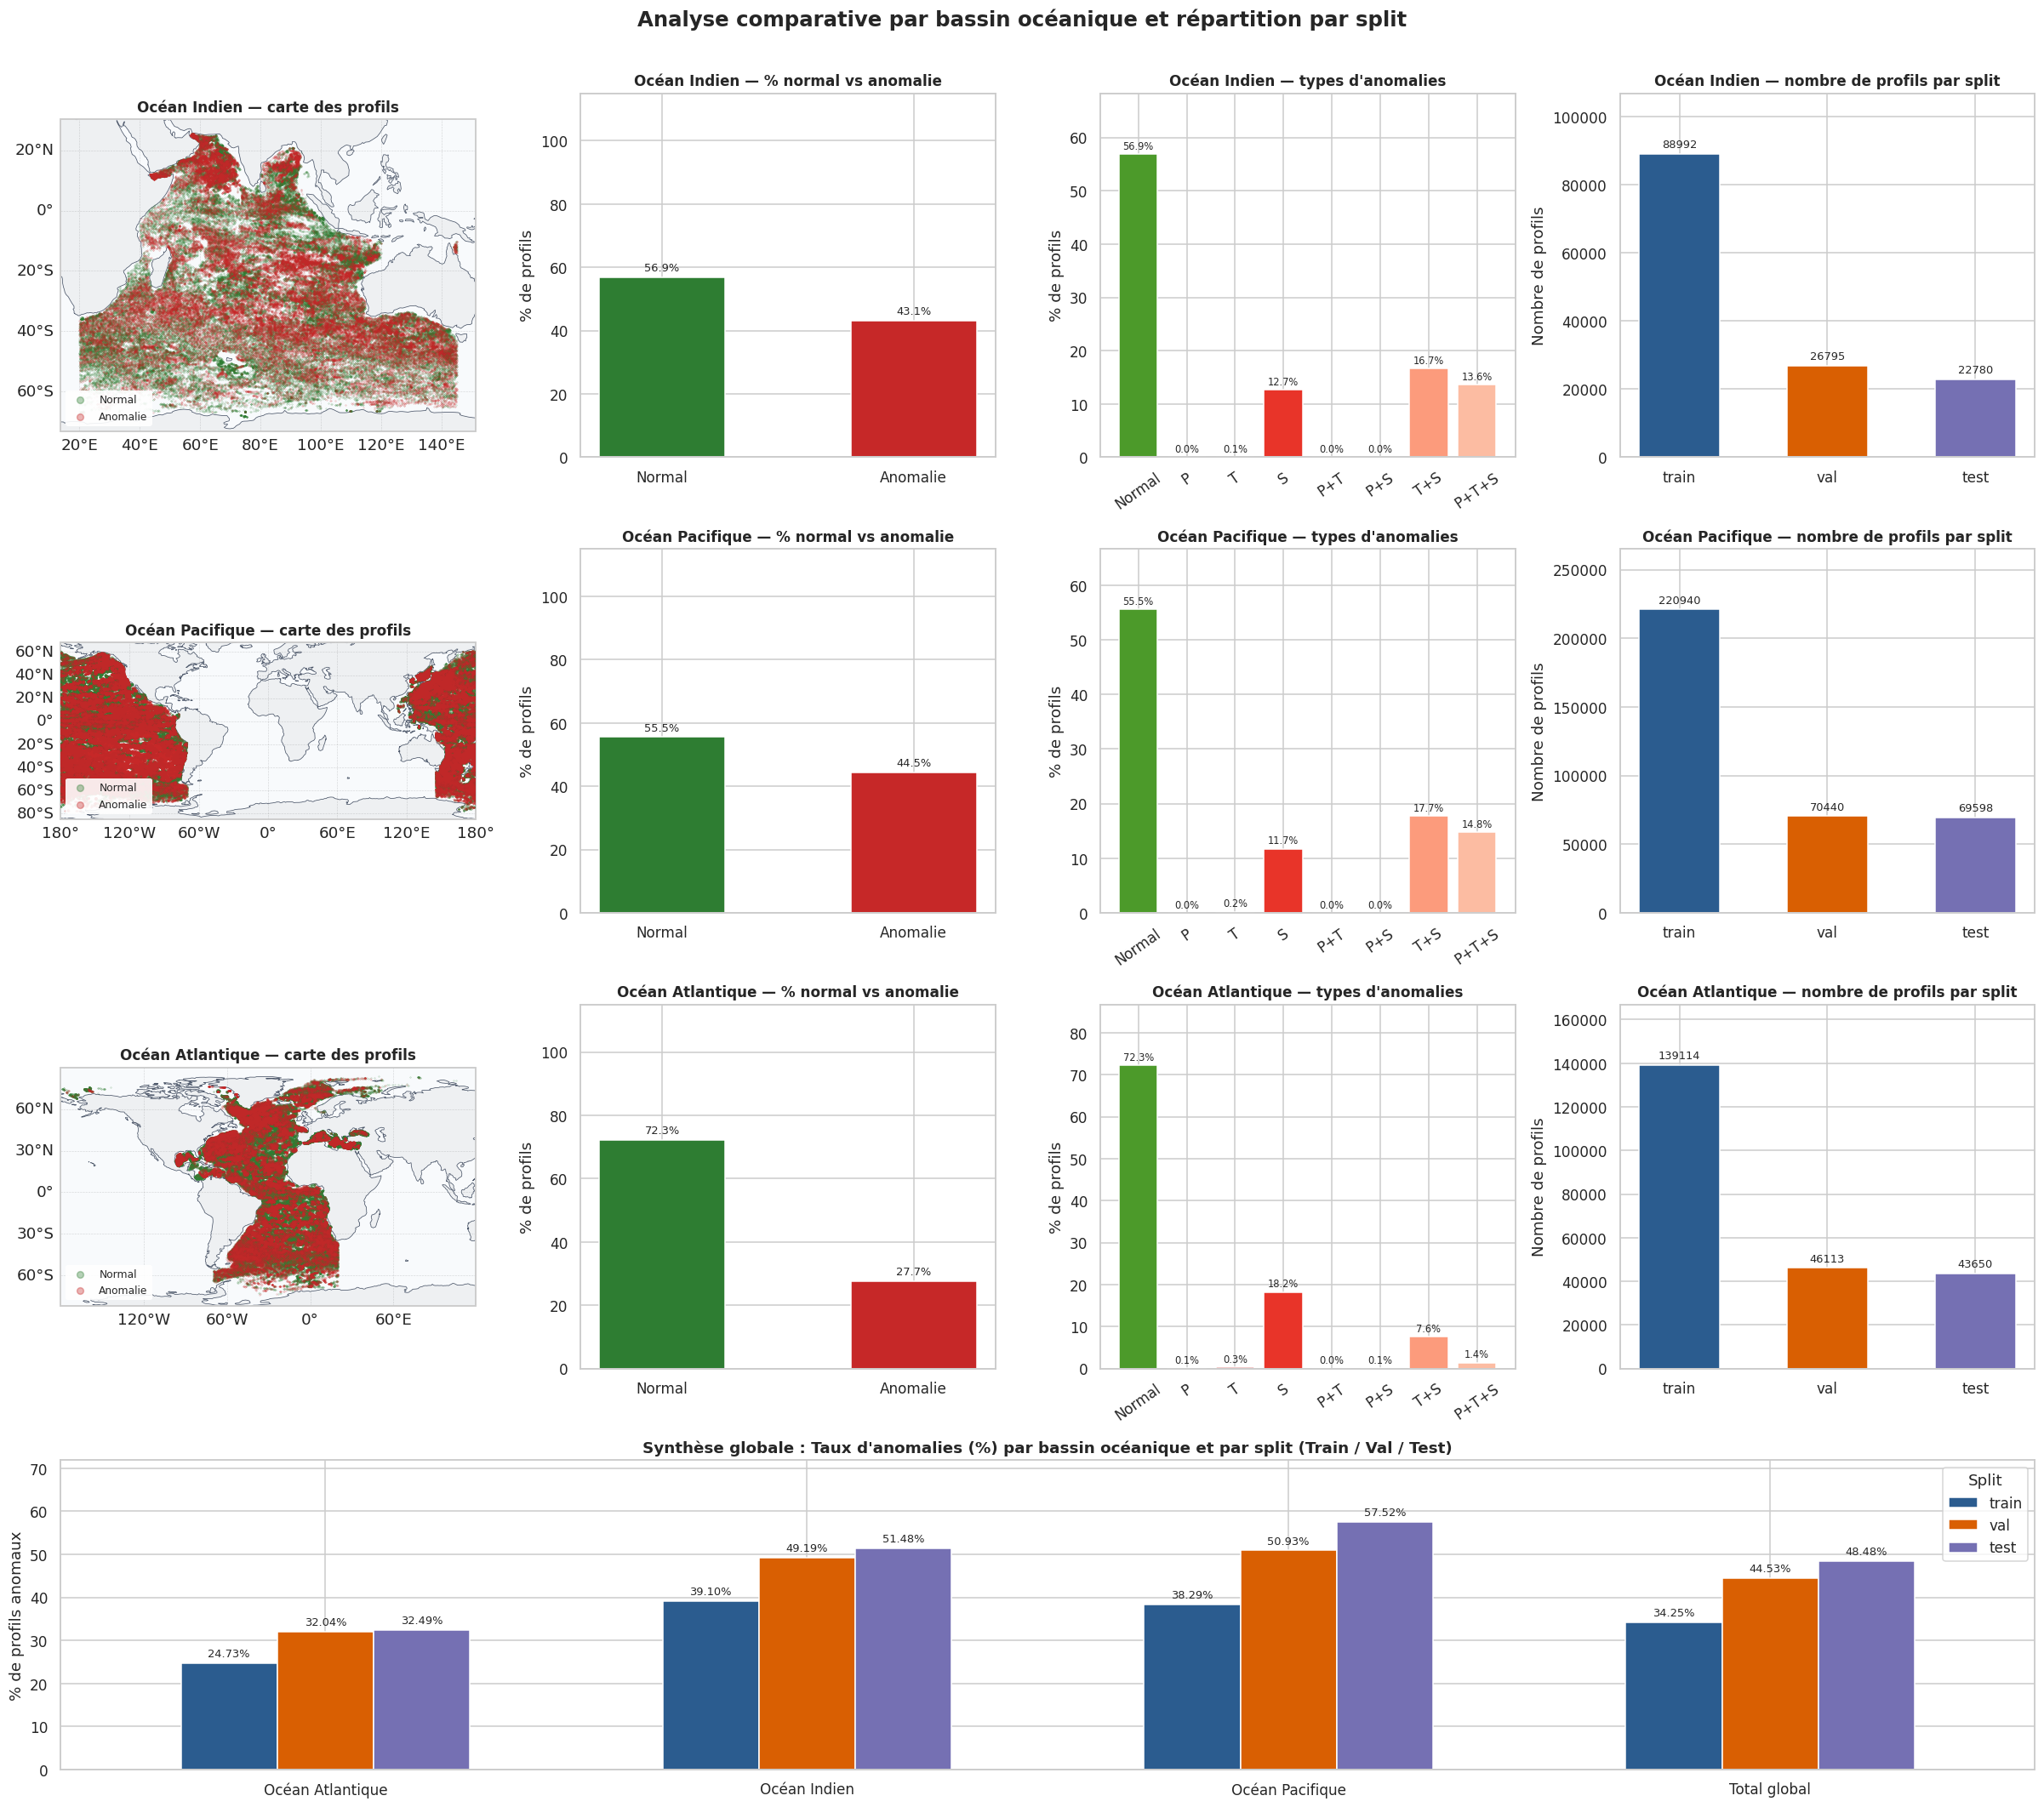

In [23]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Dictionnaire pour des noms formels d'océans en français
BASIN_NAMES_FR = {
    "ATLANTIC": "Océan Atlantique",
    "PACIFIC": "Océan Pacifique",
    "INDIAN": "Océan Indien",
    "atlantic": "Océan Atlantique",
    "pacific": "Océan Pacifique",
    "indian": "Océan Indien",
}

basins = list(data.keys())
n_basins = len(basins)

fig = plt.figure(figsize=(22, 4.8 * (n_basins + 1)))
gs = fig.add_gridspec(n_basins + 1, 4, height_ratios=[1] * n_basins + [0.85])

for i, basin in enumerate(basins):
    df = data[basin]["profiles"]
    basin_label_fr = BASIN_NAMES_FR.get(str(basin).upper(), str(basin).capitalize())

    # Col 1 : Carte géographique avec Cartopy (points réduits à s=0.1)
    ax_map = fig.add_subplot(gs[i, 0], projection=ccrs.PlateCarree())
    ax_map.add_feature(cfeature.OCEAN, facecolor="#f8fafc", zorder=0)
    ax_map.add_feature(cfeature.LAND, facecolor="#eef0f2", zorder=1)
    ax_map.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="#4a5568", zorder=2)

    for status, color in STATUS_COLORS.items():
        sub = df[df["status"] == status]
        z_idx = 3 if status == "Normal" else 4
        ax_map.scatter(
            sub["LONGITUDE"], sub["LATITUDE"],
            s=0.1, alpha=0.35, color=color, label=status,
            transform=ccrs.PlateCarree(), rasterized=True, zorder=z_idx
        )

    ax_map.set_title(f"{basin_label_fr} — carte des profils", fontsize=11, fontweight="bold")
    gl = ax_map.gridlines(
        draw_labels=True, dms=False, x_inline=False, y_inline=False,
        linewidth=0.4, color="gray", alpha=0.3, linestyle="--"
    )
    gl.top_labels = False
    gl.right_labels = False

    ax_map.legend(
        markerscale=16, loc="lower left", frameon=True,
        facecolor="white", framealpha=0.9, edgecolor="none", fontsize=8
    )

    # Col 2 : % Normal vs Anomalie
    ax_status = fig.add_subplot(gs[i, 1])
    vc = df["status"].value_counts(normalize=True).reindex(["Normal", "Anomalie"]).fillna(0) * 100
    bars_s = ax_status.bar(vc.index, vc.values, color=[STATUS_COLORS[s] for s in vc.index], edgecolor="white", width=0.5)
    ax_status.bar_label(bars_s, fmt="%.1f%%", fontsize=8.5, padding=3)
    ax_status.set_title(f"{basin_label_fr} — % normal vs anomalie", fontsize=11, fontweight="bold")
    ax_status.set_ylabel("% de profils")
    ax_status.set_ylim(0, 115)

    # Col 3 : Répartition des types d'anomalies
    ax_type = fig.add_subplot(gs[i, 2])
    tvc = df["anomaly_type"].value_counts(normalize=True).reindex(ORDER).fillna(0) * 100
    colors = ["#4C9A2A"] + list(plt.cm.Reds_r(np.linspace(0.15, 0.75, 7)))
    bars_t = ax_type.bar(tvc.index, tvc.values, color=colors, edgecolor="white")
    ax_type.bar_label(bars_t, fmt="%.1f%%", fontsize=7.5, padding=2)
    ax_type.set_title(f"{basin_label_fr} — types d'anomalies", fontsize=11, fontweight="bold")
    ax_type.tick_params(axis="x", rotation=35)
    ax_type.set_ylabel("% de profils")
    ax_type.set_ylim(0, max(tvc.max() * 1.2, 10))

    # Col 4 : Nombre total de profils par split
    ax_count = fig.add_subplot(gs[i, 3])
    split_counts = df["split"].value_counts().reindex(["train", "val", "test"]).fillna(0)
    bars_c = ax_count.bar(
        split_counts.index, split_counts.values,
        color=["#2b5c8f", "#d95f02", "#7570b3"], edgecolor="white", width=0.55
    )
    ax_count.bar_label(bars_c, fmt="%d", fontsize=8.5, padding=3)
    ax_count.set_title(f"{basin_label_fr} — nombre de profils par split", fontsize=11, fontweight="bold")
    ax_count.set_ylabel("Nombre de profils")
    ax_count.set_ylim(0, max(split_counts.max() * 1.2, 10))

# --- Ligne finale de synthèse : Taux d'anomalies par split (Train / Val / Test) ---
ax_split = fig.add_subplot(gs[n_basins, :])

anomaly_by_split = (
    df_all.groupby(["BASIN", "split"])["is_bad"]
    .mean().unstack("split")[["train", "val", "test"]] * 100
)

anomaly_by_split.index = [BASIN_NAMES_FR.get(str(b).upper(), str(b).capitalize()) for b in anomaly_by_split.index]
anomaly_by_split.loc["Total global"] = df_all.groupby("split")["is_bad"].mean()[["train", "val", "test"]] * 100

anomaly_by_split.plot(
    kind="bar", ax=ax_split, width=0.6,
    color=["#2b5c8f", "#d95f02", "#7570b3"], edgecolor="white"
)

ax_split.set_title("Synthèse globale : Taux d'anomalies (%) par bassin océanique et par split (Train / Val / Test)", fontsize=12, fontweight="bold")
ax_split.set_ylabel("% de profils anomaux")
ax_split.tick_params(axis="x", rotation=0)
ax_split.legend(title="Split", loc="upper right")
ax_split.set_ylim(0, anomaly_by_split.values.max() * 1.25)

for c in ax_split.containers:
    ax_split.bar_label(c, fmt="%.2f%%", fontsize=8.5, padding=3)

fig.suptitle("Analyse comparative par bassin océanique et répartition par split", y=1.005, fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "panneau_par_bassin.png", bbox_inches="tight", dpi=300)
plt.show()

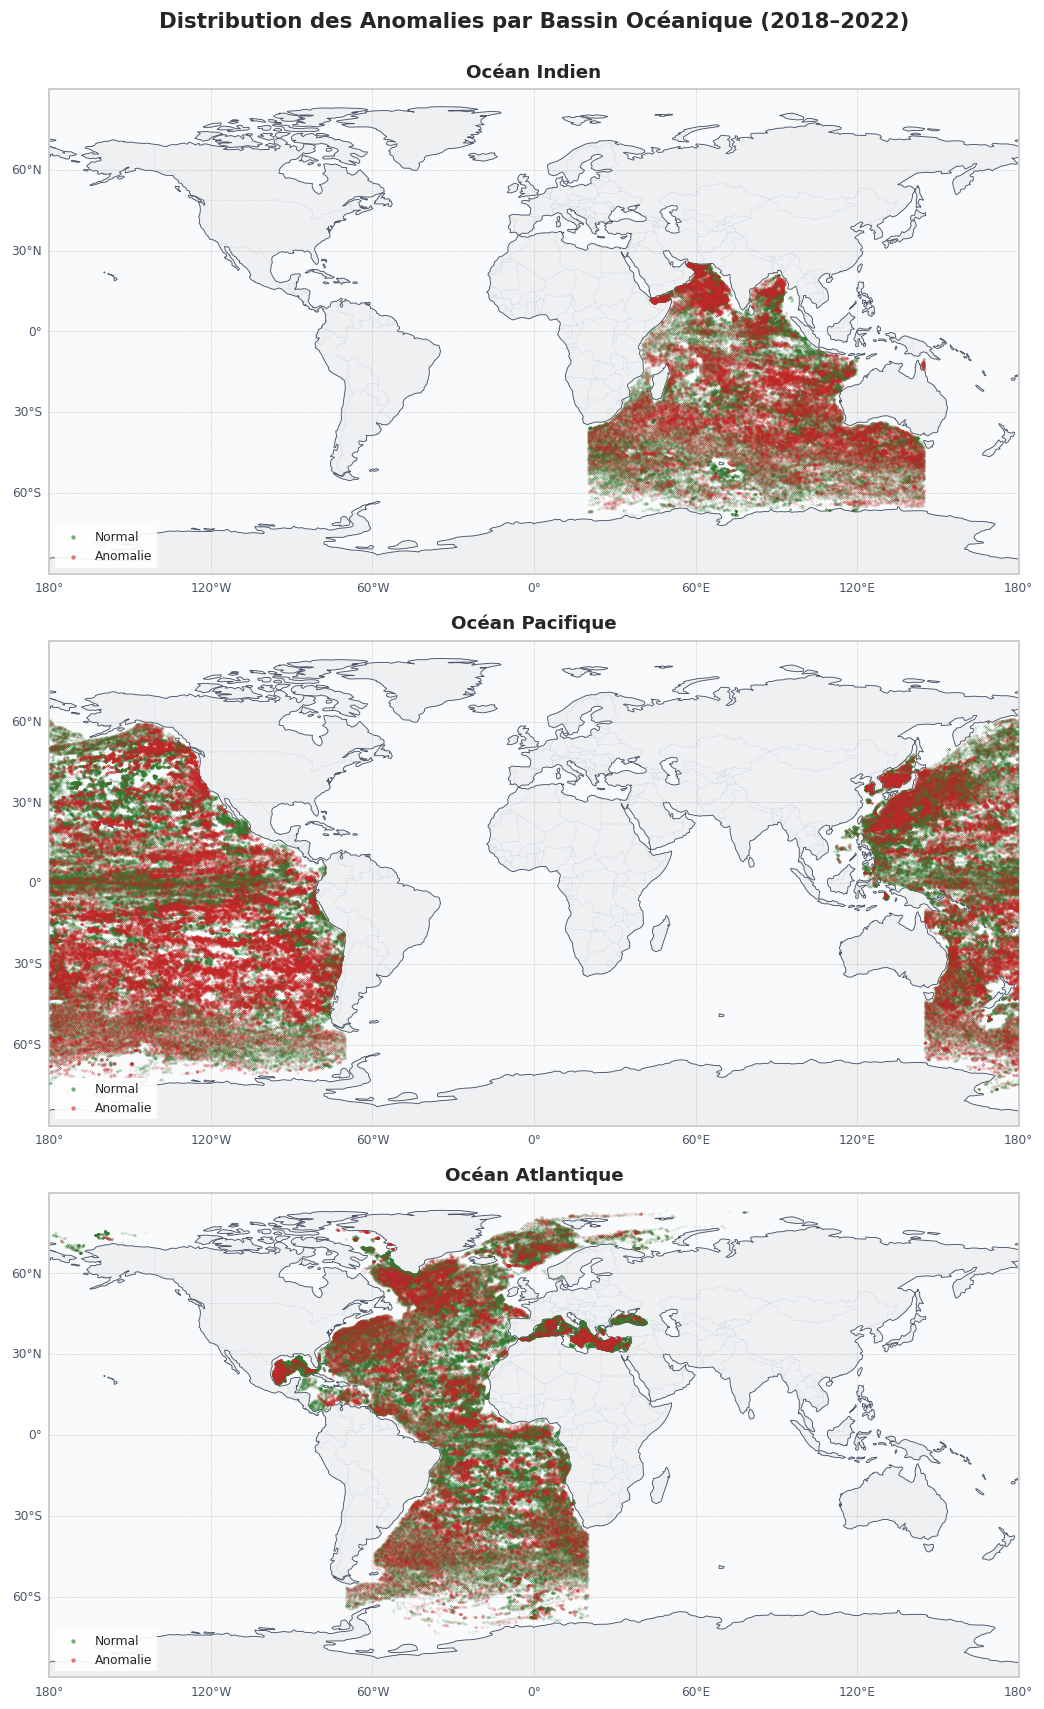

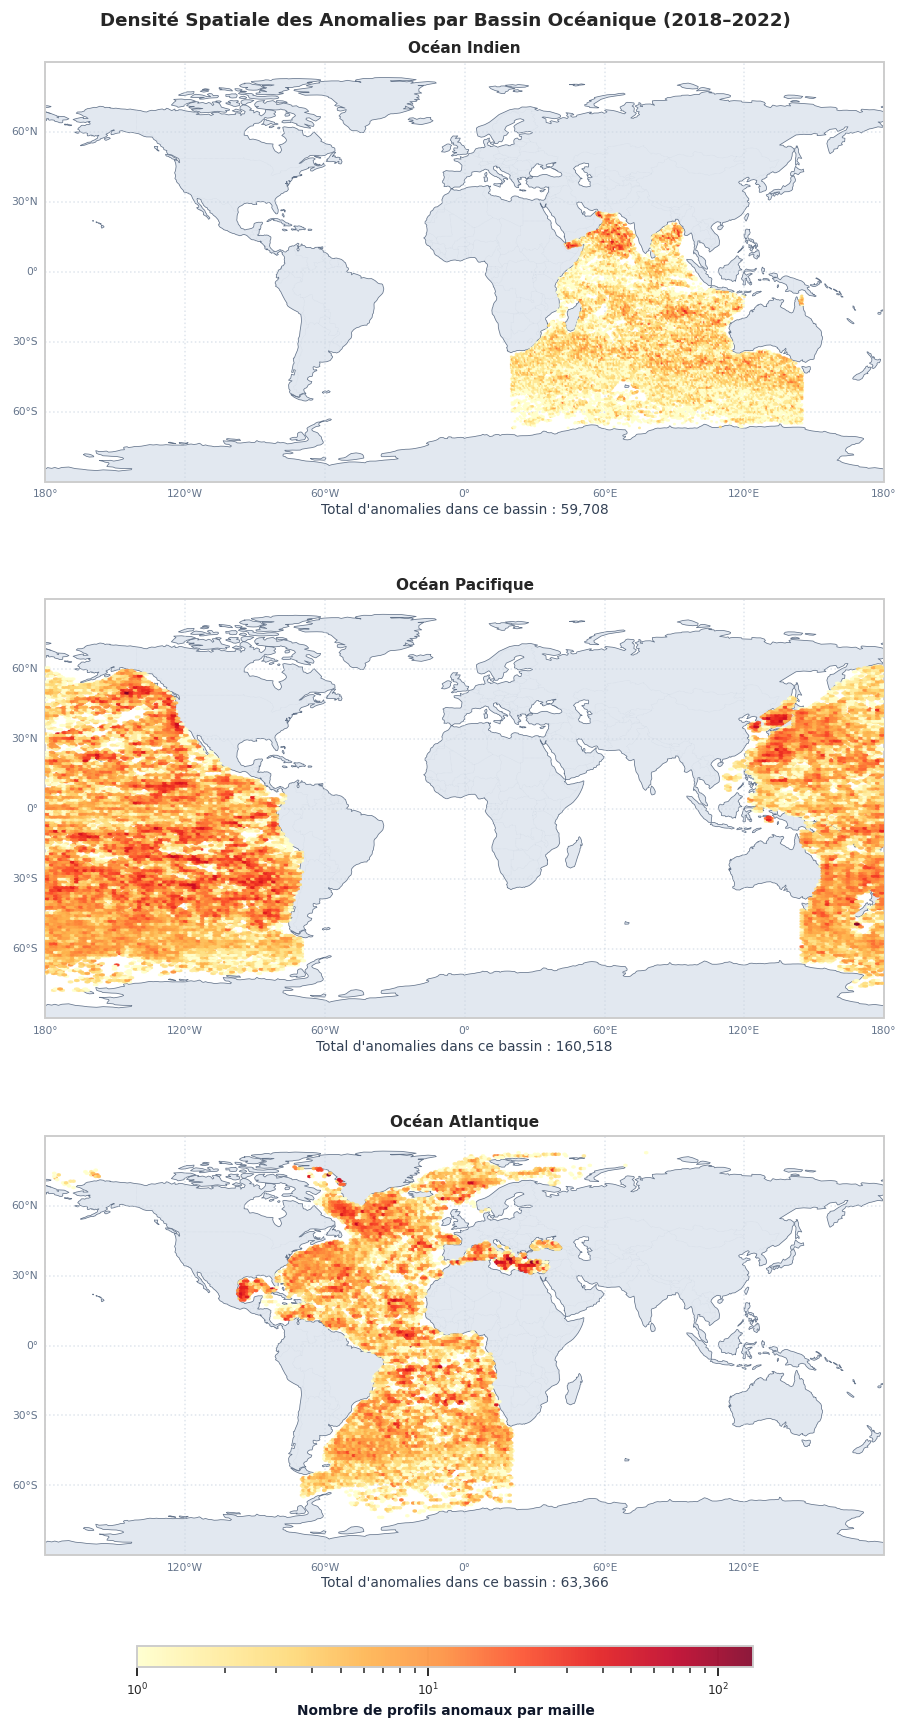

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# noms de bassins 
BASIN_NAMES_FR = {
    "ATLANTIC": "Océan Atlantique",
    "PACIFIC": "Océan Pacifique",
    "INDIAN": "Océan Indien",
    "atlantic": "Océan Atlantique",
    "pacific": "Océan Pacifique",
    "indian": "Océan Indien",
}

basins = list(data.keys())
n_basins = len(basins)

# 1. SCATTER PLOT PAR BASSIN 
fig_sc, axes_sc = plt.subplots(
    n_basins, 1, 
    figsize=(14, 5.2 * n_basins), 
    subplot_kw={'projection': ccrs.PlateCarree(central_longitude=0)}
)
if n_basins == 1:
    axes_sc = [axes_sc]

for i, basin in enumerate(basins):
    ax = axes_sc[i]
    df_b = data[basin]["profiles"].copy()
    basin_str = str(basin).upper()
    basin_label = BASIN_NAMES_FR.get(basin_str, str(basin).capitalize())

    # Fond de carte global complet
    ax.add_feature(cfeature.OCEAN, facecolor="#f8fafc", zorder=0)
    ax.add_feature(cfeature.LAND, facecolor="#eef0f2", zorder=1)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6, edgecolor="#4a5568", zorder=2)
    ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.3, edgecolor="#a0aec0", zorder=2)

    # Vue globale 
    ax.set_global()

    lons = df_b["LONGITUDE"].to_numpy()
    if basin_str == "PACIFIC":
        lons = np.where(lons < 0, lons + 360, lons)

    gl = ax.gridlines(draw_labels=True, linewidth=0.4, color="gray", alpha=0.4, linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {"size": 8, "color": "#4a5568"}
    gl.ylabel_style = {"size": 8, "color": "#4a5568"}

    for status in ["Normal", "Anomalie"]:
        if status in STATUS_COLORS:
            sub_mask = df_b["status"] == status
            z_idx = 3 if status == "Normal" else 4
            
            ax.scatter(
                lons[sub_mask], df_b.loc[sub_mask, "LATITUDE"],
                s=0.03,
                alpha=0.45,
                color=STATUS_COLORS[status],
                label=status,
                transform=ccrs.PlateCarree(), 
                rasterized=True, 
                zorder=z_idx
            )

    # Titre 
    ax.set_title(f"{basin_label}", fontsize=12, fontweight="bold", pad=8)
    
    ax.legend(
        loc="lower left",
        frameon=True,
        facecolor="white",
        framealpha=0.9,
        edgecolor="none",
        fontsize=8,
        markerscale=12
    )

fig_sc.suptitle("Distribution des Anomalies par Bassin Océanique (2018–2022)", fontsize=14, fontweight="bold", y=0.995)
plt.tight_layout()
plt.savefig(FIG_DIR / "map_scatter_by_basin.png", bbox_inches="tight", dpi=300)
plt.show()

# 2. DENSITY HEXBIN PLOT PAR BASSIN 
fig_hex, axes_hex = plt.subplots(
    n_basins, 1, 
    figsize=(14, 5.2 * n_basins), 
    subplot_kw={'projection': ccrs.PlateCarree(central_longitude=0)}
)
if n_basins == 1:
    axes_hex = [axes_hex]

last_hb = None

for i, basin in enumerate(basins):
    ax = axes_hex[i]
    df_b = data[basin]["profiles"].copy()
    df_bad = df_b[df_b["is_bad"] == 1]
    basin_str = str(basin).upper()
    basin_label = BASIN_NAMES_FR.get(basin_str, str(basin).capitalize())

    # Fond de carte global
    ax.add_feature(cfeature.LAND, facecolor="#e2e8f0", edgecolor="none", zorder=1)
    ax.add_feature(cfeature.OCEAN, facecolor="#ffffff", zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="#64748b", zorder=2)
    ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.3, edgecolor="#cbd5e1", zorder=2)

    ax.set_global()

    gl = ax.gridlines(draw_labels=True, color="#cbd5e1", linestyle=":", alpha=0.6)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {"size": 7, "color": "#64748b"}
    gl.ylabel_style = {"size": 7, "color": "#64748b"}

    # Transformation des longitudes pour le Pacifique
    lons_bad = df_bad["LONGITUDE"].to_numpy()
    if basin_str == "PACIFIC":
        lons_bad = np.where(lons_bad < 0, lons_bad + 360, lons_bad)

    last_hb = ax.hexbin(
        lons_bad,
        df_bad["LATITUDE"].to_numpy(),
        gridsize=200,
        cmap="YlOrRd",
        mincnt=1,
        norm=mcolors.LogNorm(),
        transform=ccrs.PlateCarree(),
        zorder=3,
        alpha=0.9
    )

    # Titre 
    ax.set_title(f"{basin_label}", fontsize=10, fontweight="bold", pad=6)
    
    # Texte sous la carte
    ax.text(
        0.5, -0.05, f"Total d'anomalies dans ce bassin : {len(df_bad):,}",
        transform=ax.transAxes, ha="center", va="top",
        fontsize=9, color="#334155", fontweight="medium"
    )

# Titre principal
fig_hex.suptitle("Densité Spatiale des Anomalies par Bassin Océanique (2018–2022)", fontsize=12, fontweight="bold", y=0.98)

if last_hb is not None:
    # Barre de couleur 
    cbar_ax = fig_hex.add_axes([0.30, 0.015, 0.40, 0.012])
    cbar = fig_hex.colorbar(last_hb, cax=cbar_ax, orientation="horizontal")
    cbar.set_label("Nombre de profils anomaux par maille", fontsize=9, fontweight="bold", color="#0f172a")
    cbar.ax.tick_params(labelsize=8)

# Ajustement global des marges 
fig_hex.subplots_adjust(hspace=0.28, top=0.95, bottom=0.08)

plt.savefig(FIG_DIR / "map_density_hexbin_by_basin.png", bbox_inches="tight", dpi=300)
plt.show()

Graphique sauvegardé dans : /home/drgarcia/Argo_ml_code_clean/4.Plots/general/figures/nombre_profils_par_bassin_split.png


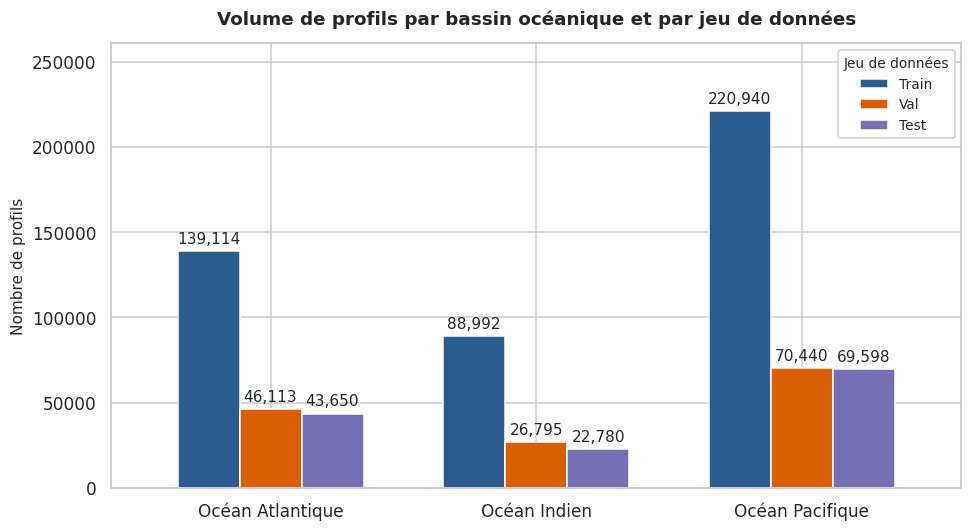

In [41]:
import matplotlib.pyplot as plt
import pandas as pd

# Couleurs pour les jeux de données (Train, Val, Test)
SPLIT_COLORS = ["#2b5c8f", "#d95f02", "#7570b3"]

# Dictionnaire de traduction des bassins en français
BASIN_NAMES_FR = {
    "ATLANTIC": "Océan Atlantique",
    "PACIFIC": "Océan Pacifique",
    "INDIAN": "Océan Indien",
    "atlantic": "Océan Atlantique",
    "pacific": "Océan Pacifique",
    "indian": "Océan Indien",
}

# Calcul du nombre total de profils par bassin et par split
counts_by_split = (
    df_all.groupby(["BASIN", "split"])
    .size()
    .unstack("split")[["train", "val", "test"]]
    .fillna(0)
)

# Application de la traduction en français
counts_by_split.index = [
    BASIN_NAMES_FR.get(str(b).upper(), str(b).capitalize()) 
    for b in counts_by_split.index
]

fig, ax = plt.subplots(figsize=(9, 5))

# Plot des barres groupées
counts_by_split.plot(
    kind="bar", ax=ax, width=0.7,
    color=SPLIT_COLORS, edgecolor="white"
)

# Titres et étiquettes
ax.set_title("Volume de profils par bassin océanique et par jeu de données", fontsize=12, pad=12)
ax.set_ylabel("Nombre de profils", fontsize=10)
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=0)
ax.legend(
    title="Jeu de données", 
    labels=["Train", "Val", "Test"], 
    loc="upper right", 
    frameon=True, 
    facecolor="white", 
    framealpha=0.9,
    fontsize=9,        # Taille du texte (Train, Val, Test)
    title_fontsize=9,  # Taille du titre ("Jeu de données")
)

# Ajustement de la limite verticale pour les étiquettes et formatage avec espaceur de milliers
max_val = counts_by_split.values.max()
ax.set_ylim(0, max_val * 1.18)

for c in ax.containers:
    ax.bar_label(c, fmt="{:,.0f}", fontsize=10, padding=3)

output_path = FIG_DIR / "nombre_profils_par_bassin_split.png"

plt.tight_layout()
plt.savefig(output_path, bbox_inches="tight", dpi=300)
print(f"Graphique sauvegardé dans : {output_path.resolve()}")
plt.show()

Graphique sauvegardé dans : /home/drgarcia/Argo_ml_code_clean/4.Plots/general/figures/repartition_types_anomalies_par_bassin.png


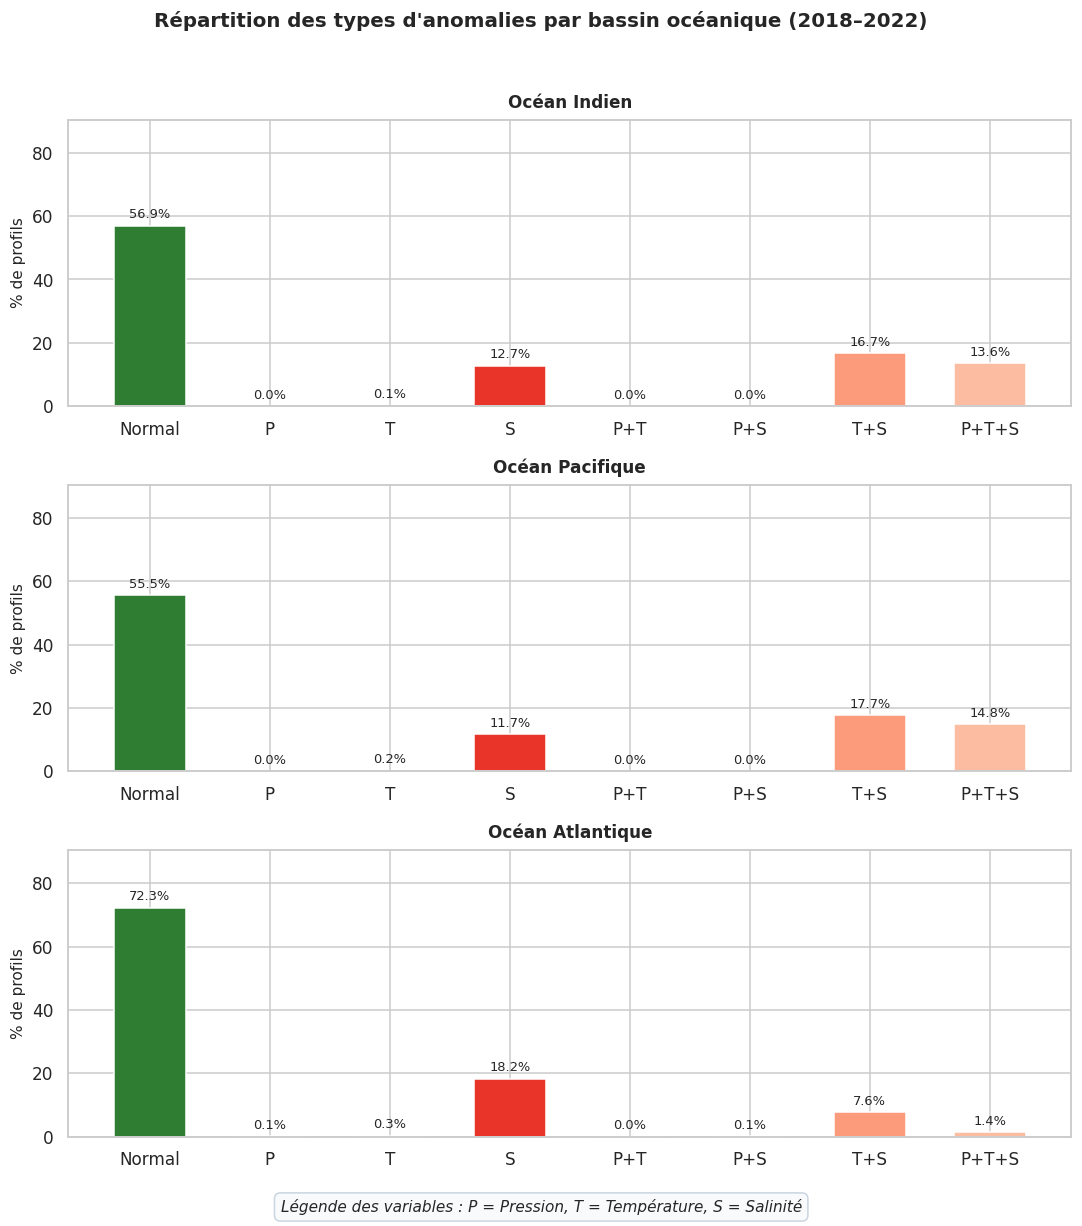

In [27]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Traduction des bassins en français
BASIN_NAMES_FR = {
    "ATLANTIC": "Océan Atlantique",
    "PACIFIC": "Océan Pacifique",
    "INDIAN": "Océan Indien",
    "atlantic": "Océan Atlantique",
    "pacific": "Océan Pacifique",
    "indian": "Océan Indien",
}

basins = list(data.keys())
n_basins = len(basins)

# Figure : 1 ligne par bassin
fig, axes = plt.subplots(n_basins, 1, figsize=(10, 3.5 * n_basins), sharey=True)
if n_basins == 1:
    axes = [axes]

# Dégradé de couleurs pour les types d'erreurs
colors = ["#2e7d32"] + list(plt.cm.Reds_r(np.linspace(0.15, 0.75, len(ORDER) - 1)))

for i, basin in enumerate(basins):
    ax = axes[i]
    df = data[basin]["profiles"]
    basin_label_fr = BASIN_NAMES_FR.get(str(basin).upper(), str(basin).capitalize())

    # Calcul du % de chaque type d'anomalie
    tvc = df["anomaly_type"].value_counts(normalize=True).reindex(ORDER).fillna(0) * 100

    bars = ax.bar(tvc.index, tvc.values, color=colors, edgecolor="white", width=0.6)
    ax.bar_label(bars, fmt="%.1f%%", fontsize=8.5, padding=3)

    # Sous-titre unique avec le nom du bassin
    ax.set_title(basin_label_fr, fontsize=11, fontweight="bold", pad=8)
    ax.set_ylabel("% de profils", fontsize=10)
    ax.tick_params(axis="x", rotation=0)
    ax.set_ylim(0, max(tvc.max() * 1.25, 15))

# Titre général au-dessus de la figure
fig.suptitle("Répartition des types d'anomalies par bassin océanique (2018–2022)", fontsize=13, fontweight="bold", y=1.02)

# Note explicative en bas de figure
legend_note = "Légende des variables : P = Pression, T = Température, S = Salinité"
fig.text(0.5, -0.02, legend_note, ha="center", fontsize=10, fontstyle="italic", 
         bbox=dict(boxstyle="round,pad=0.4", facecolor="#f8fafc", edgecolor="#cbd5e1"))

output_path = FIG_DIR / "repartition_types_anomalies_par_bassin.png"

plt.tight_layout()
plt.savefig(output_path, bbox_inches="tight", dpi=300)
print(f"Graphique sauvegardé dans : {output_path.resolve()}")
plt.show()

## 10. Dataset Summary Panel

- Layout: A dashboard-style figure combining all three ocean basins.

- Content: Basin-colored global profile map, Overall anomaly rate, Global anomaly type distribution, Monthly time series of profile counts.

- Purpose: Designed as a comprehensive macro-level overview for the report.


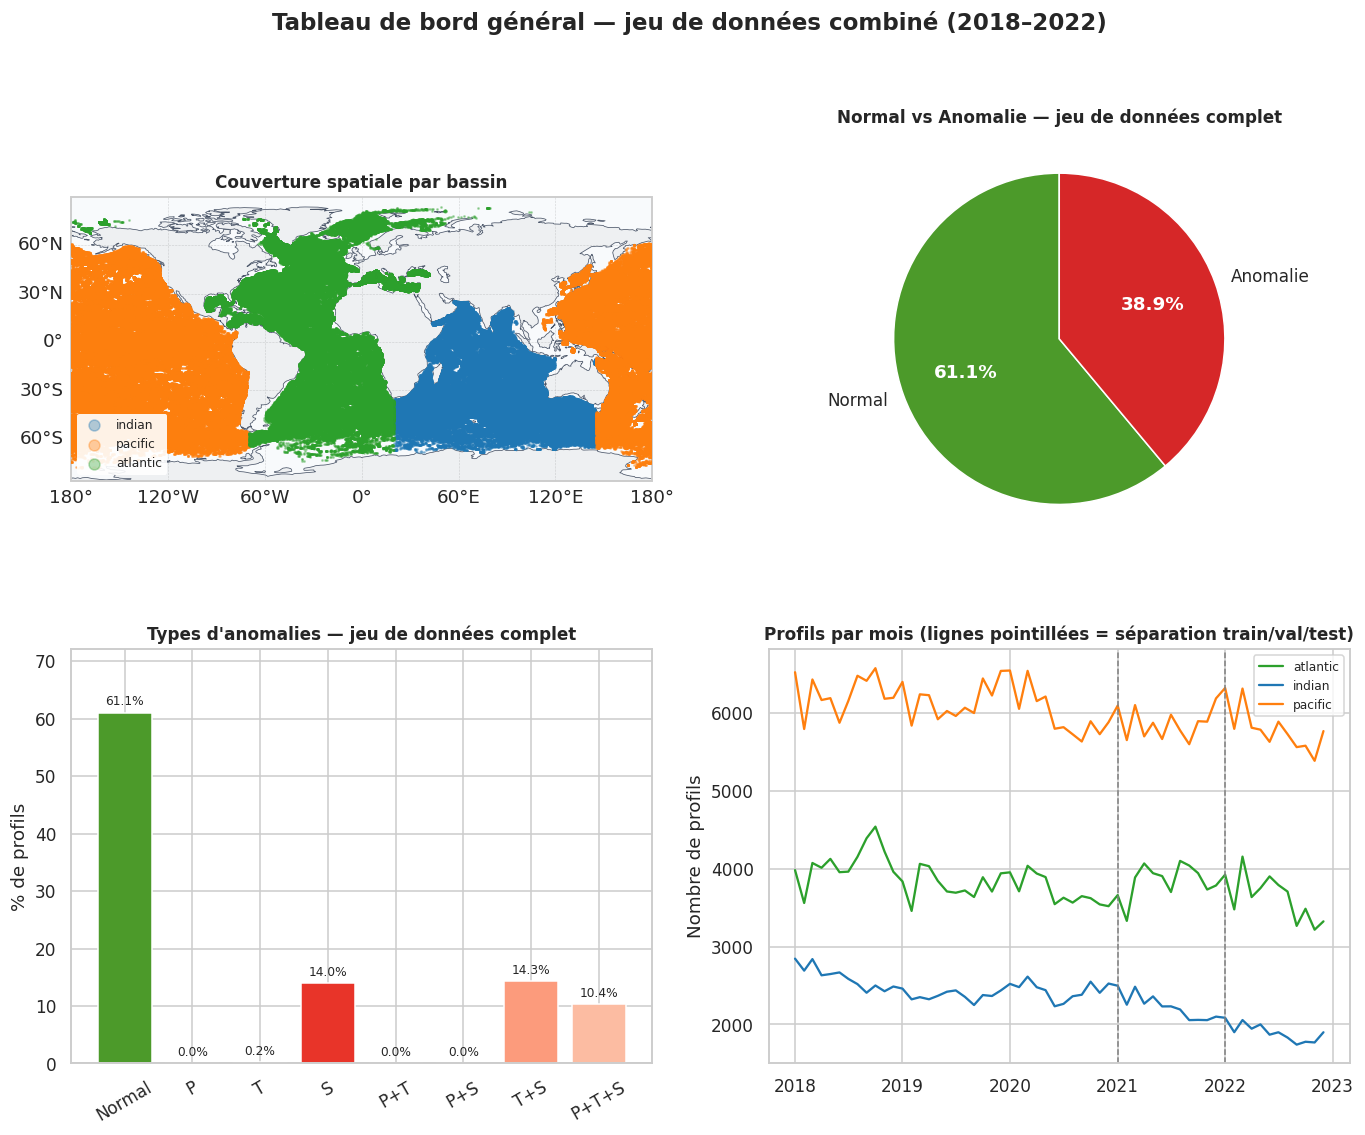

In [14]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(15, 11))
gs = fig.add_gridspec(2, 2, hspace=0.25, wspace=0.2)

# 1. Carte de couverture spatiale avec Cartopy
ax_map = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree())
ax_map.add_feature(cfeature.OCEAN, facecolor="#f8fafc", zorder=0)
ax_map.add_feature(cfeature.LAND, facecolor="#eef0f2", zorder=1)
ax_map.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="#4a5568", zorder=2)

for basin, color in BASIN_COLORS.items():
    if basin not in data:
        continue
    sub = df_all[df_all["BASIN"] == basin]
    ax_map.scatter(
        sub["LONGITUDE"], sub["LATITUDE"],
        s=0.8, alpha=0.35, color=color, label=str(basin).lower(),
        transform=ccrs.PlateCarree(), rasterized=True, zorder=3
    )

gl = ax_map.gridlines(
    draw_labels=True, dms=False, x_inline=False, y_inline=False,
    linewidth=0.4, color="gray", alpha=0.3, linestyle="--"
)
gl.top_labels = False
gl.right_labels = False

ax_map.set_title("Couverture spatiale par bassin", fontsize=11, fontweight="bold")
ax_map.legend(
    markerscale=8, loc="lower left", frameon=True,
    facecolor="white", framealpha=0.9, edgecolor="none", fontsize=8
)

# 2. % d'anomalies global
ax_pie = fig.add_subplot(gs[0, 1])
vc = df_all["status"].value_counts(normalize=True).reindex(["Normal", "Anomalie"]) * 100
wedges, texts, autotexts = ax_pie.pie(
    vc.values, labels=vc.index, autopct="%.1f%%",
    colors=[STATUS_COLORS[s] for s in vc.index], startangle=90,
    wedgeprops={"edgecolor": "white"}
)
for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_weight("bold")
ax_pie.set_title("Normal vs Anomalie — jeu de données complet", fontsize=11, fontweight="bold")

# 3. Types d'anomalies global
ax_bar = fig.add_subplot(gs[1, 0])
tvc = df_all["anomaly_type"].value_counts(normalize=True).reindex(ORDER).fillna(0) * 100
colors = ["#4C9A2A"] + list(plt.cm.Reds_r(np.linspace(0.15, 0.75, 7)))
bars = ax_bar.bar(tvc.index, tvc.values, color=colors, edgecolor="white")
ax_bar.bar_label(bars, fmt="%.1f%%", fontsize=8, padding=3)
ax_bar.set_ylim(0, tvc.max() * 1.18)
ax_bar.set_title("Types d'anomalies — jeu de données complet", fontsize=11, fontweight="bold")
ax_bar.tick_params(axis="x", rotation=30)
ax_bar.set_ylabel("% de profils")

# 4. Évolution temporelle (profils par mois, par bassin)
ax_time = fig.add_subplot(gs[1, 1])
monthly = (
    df_all.set_index("date").groupby([pd.Grouper(freq="MS"), "BASIN"])
    .size().unstack("BASIN").fillna(0)
)
for basin in monthly.columns:
    ax_time.plot(monthly.index, monthly[basin], color=BASIN_COLORS[basin], label=str(basin).lower(), lw=1.5)

ax_time.axvline(TRAIN_END, color="grey", ls="--", lw=1)
ax_time.axvline(VAL_END, color="grey", ls="--", lw=1)
ax_time.set_title("Profils par mois (lignes pointillées = séparation train/val/test)", fontsize=11, fontweight="bold")
ax_time.set_ylabel("Nombre de profils")
ax_time.legend(fontsize=8, loc="upper right")

fig.suptitle("Tableau de bord général — jeu de données combiné (2018–2022)", y=0.98,
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "dashboard_general.png", bbox_inches="tight", dpi=300)
plt.show()

## 11. Summary Table 

- Content: Merges all key metrics per basin and overall totals into a single, exportable summary table.

- Purpose: Provides a unified numerical reference for the report.

In [15]:
rows = []
for basin, d in list(data.items()):
    df = d["profiles"]
    rows.append({
        "Bassin": basin,
        "N profils": len(df),
        "N flotteurs uniques": df["PLATFORM_NUMBER"].nunique(),
        "% d'anomalies": round(df["is_bad"].mean() * 100, 2),
        "% P uniquement": round((df["anomaly_type"] == "P").mean() * 100, 2),
        "% T uniquement": round((df["anomaly_type"] == "T").mean() * 100, 2),
        "% S uniquement": round((df["anomaly_type"] == "S").mean() * 100, 2),
        "% P+T": round((df["anomaly_type"] == "P+T").mean() * 100, 2),
        "% P+S": round((df["anomaly_type"] == "P+S").mean() * 100, 2),
        "% T+S": round((df["anomaly_type"] == "T+S").mean() * 100, 2),
        "% P+T+S": round((df["anomaly_type"] == "P+T+S").mean() * 100, 2),
        "N niveaux (moyenne)": round(df["n_levels"].mean(), 1),
        "N flotteurs train": platform_stats[basin].loc["train", "n_flotteurs"],
        "N flotteurs val (nouveaux)": platform_stats[basin].loc["val", "n_flotteurs_nouveaux"],
        "N flotteurs test (nouveaux)": platform_stats[basin].loc["test", "n_flotteurs_nouveaux"],
    })

df_final_summary = pd.DataFrame(rows).set_index("Bassin")
df_final_summary.to_csv(TAB_DIR / "resume_final_rapport.csv")
df_final_summary

,N profils,N flotteurs uniques,% d'anomalies,% P uniquement,% T uniquement,% S uniquement,% P+T,% P+S,% T+S,% P+T+S,N niveaux (moyenne),N flotteurs train,N flotteurs val (nouveaux),N flotteurs test (nouveaux)
Bassin,,,,,,,,,,,,,,
Indian,138567,1521,43.09,0.01,0.08,12.71,0.0,0.01,16.70,13.59,597.5,1340,78,169
Pacific,360978,3617,44.47,0.01,0.21,11.73,0.0,0.01,17.72,14.80,658.2,2928,399,659
Atlantic,228877,2410,27.69,0.13,0.26,18.23,0.0,0.06,7.61,1.39,507.8,1882,289,495
